# Motor vs potmon vs IMU — raw streams

File: `metadata_20260627_173152.h5`. Only the **azimuth** motor was moving.

Step 1: plot the raw azimuth-relevant streams versus time, no processing.

- **motor** — `az_pos`, `az_target_pos` (encoder step counts)
- **potmon** — `pot_az_voltage` (raw ADC volts; cal slope/intercept are null in this file)
- **imu_az** — `yaw`, `pitch`, `roll` (degrees, BNO085 RVC)

`imu_el` is all `status=error` in this file (elevation IMU dead) and is not plotted.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from eigsep_observing.io import read_metadata_hdf5

# Locate the data file by walking up from the notebook directory.
FNAME = "metadata_20260627_173152.h5"
here = Path.cwd()
data_path = next(
    (p / FNAME for p in [here, *here.parents] if (p / FNAME).exists()),
    None,
)
assert data_path is not None, f"could not find {FNAME} above {here}"
print("reading", data_path)

meta = read_metadata_hdf5(data_path)
{k: len(v) for k, v in meta.items()}

reading /home/christian/Documents/research/eigsep/eigsep_observing/metadata_20260627_173152.h5


{'imu_az': 1922,
 'imu_el': 1890,
 'lidar': 1925,
 'motor': 1564,
 'potmon': 1928,
 'tempctrl_lna': 1903,
 'tempctrl_load': 1903}

In [2]:
# Global t0 across the three streams of interest, so all panels share a
# common time origin (seconds since the first sample).
STREAMS = ["motor", "potmon", "imu_az"]
all_ts = [
    s["_ts_unix"]
    for k in STREAMS
    for s in meta[k]
    if s is not None
]
T0 = min(all_ts)


def series(stream, field, drop_error=True):
    """Return (t_seconds_since_T0, values) for one field of one stream.

    Drops None samples (dropped readings) and, by default, samples whose
    own status is 'error' (errored-sample data is junk, per the metadata
    contract). Raw otherwise -- no averaging, no unwrapping.
    """
    t, y = [], []
    for s in meta[stream]:
        if s is None:
            continue
        if drop_error and s.get("status") == "error":
            continue
        val = s.get(field)
        if val is None:
            continue
        t.append(s["_ts_unix"] - T0)
        y.append(val)
    return np.asarray(t), np.asarray(y)

saved /home/christian/Documents/research/eigsep/eigsep_observing/notebooks/motor_pot_imu/01_raw_streams.png


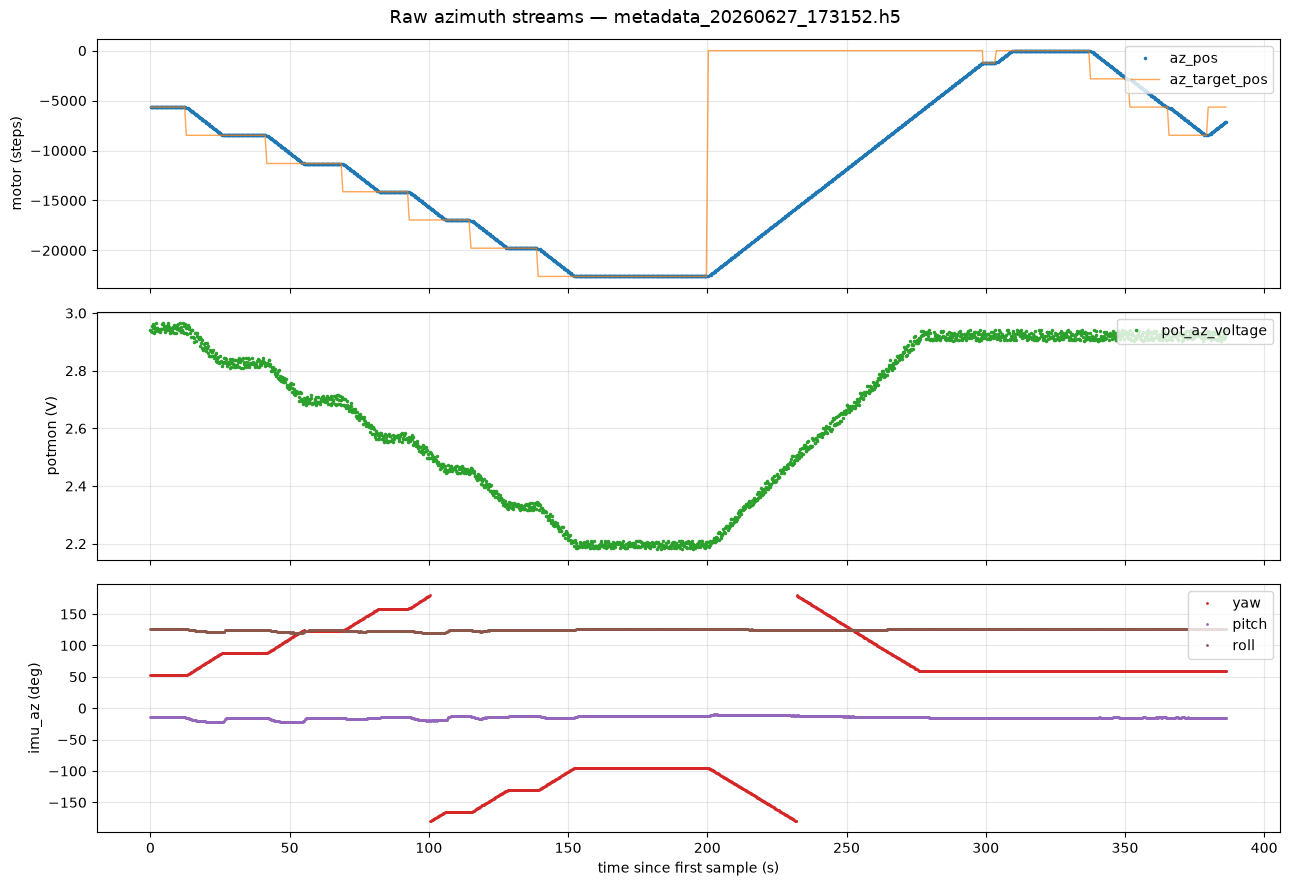

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# --- motor (step counts) ---
t, y = series("motor", "az_pos")
axes[0].plot(t, y, ".", ms=3, label="az_pos")
t, y = series("motor", "az_target_pos")
axes[0].plot(t, y, "-", lw=1, alpha=0.7, label="az_target_pos")
axes[0].set_ylabel("motor (steps)")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# --- potmon (raw volts) ---
t, y = series("potmon", "pot_az_voltage")
axes[1].plot(t, y, ".", ms=3, color="tab:green", label="pot_az_voltage")
axes[1].set_ylabel("potmon (V)")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

# --- imu_az (degrees) ---
for field, color in [
    ("yaw", "tab:red"),
    ("pitch", "tab:purple"),
    ("roll", "tab:brown"),
]:
    t, y = series("imu_az", field)
    axes[2].plot(t, y, ".", ms=2, color=color, label=field)
axes[2].set_ylabel("imu_az (deg)")
axes[2].set_xlabel("time since first sample (s)")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)

fig.suptitle(
    "Raw azimuth streams \u2014 metadata_20260627_173152.h5", fontsize=13
)
fig.tight_layout()
out = Path.cwd() / "01_raw_streams.png"
fig.savefig(out, dpi=120, bbox_inches="tight")
print("saved", out)